# CIC3 Strategy × Topology Comparison

Compares CIC3 seeding strategies — random, high-degree, high-2-simplex,
community-Louvain, and community-farthest-first — across topologies
(RSC, PA, SBM × 2, PSO-Community, Twitter-collapse, Twitter-mutual).

For each (topology, strategy) we run `NUM_TRIALS` independent simulations
and aggregate the results. Headline output: bar charts of mean `A_g` and
`A_g^td` with error bars (trial std), plus per-topology boxplots of
per-contagion attainment to show how evenly each strategy fills quotas
across contagions.

Quotas are chosen so `sum(Q_i) == N` (no slack) so strategy differences
actually surface in the metric.

The two community strategies detect clusters dynamically from the graph:

- **Louvain**: single-level modularity optimization, then rank detected
  communities by intra-endpoint density so hub-like communities sink to
  the bottom of the ranking. Each contagion takes a distinct top-ranked
  community and seeds its internally-best-connected nodes.
- **Farthest-First**: pick C maximally-separated BFS centers (avoiding
  the highest-degree anchor), then grow a degree-prioritized BFS-ball
  of seeds around each center, keeping balls disjoint.

`SBM 52 Communities With Hubs` is specifically designed to stress
community strategies: 52 tight small communities (size 9) + 1 hubby
community (size 32) with high hub-to-everyone connectivity. With C=50
< K=53 the community strategies can drop the hub entirely.

`PSO Community` adds the previously missing combination of a power-law
degree distribution **and** community structure: 50 Gaussian-mixture
communities on the similarity circle with a popularity-fading exponent
`gamma ≈ 3`, targeting the observation in the README notes that the
`Twitter Mutual` result (Random beating High Degree) may require both
scale-free degree and community structure to reproduce on a synthetic
topology.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from scm import (
    RSCGenerator, BAGenerator, SBMGenerator, TwitterEgoGenerator,
    PSOCommunityGenerator, CIC3Simulator,
)
from scm import (
    MultiRandomSeeding, MultiHighDegreeSeeding, MultiHighSimplexSeeding,
    CommunityLouvainSeeding, CommunityFarthestFirstSeeding,
)
from scm.analysis import (
    attainment, time_discounted_attainment,
    exponential_decay, linear_decay, no_decay,
)

STRATEGIES = [
    ("Random", MultiRandomSeeding),
    ("High Degree", MultiHighDegreeSeeding),
    ("High 2-Simplex", MultiHighSimplexSeeding),
    ("Louvain", CommunityLouvainSeeding),
    ("Farthest-First", CommunityFarthestFirstSeeding),
]

## Shared parameters

In [3]:
# --- Topology / network parameters ---
# `N` only applies to the synthetic topologies (RSC, BA, SBM, SBM-Manual).
# Twitter topologies derive their own N from the data.
N = 500
K_AVG_TARGET = 20
K_D_AVG_TARGET = 6
TOPO_SEED = 2025

# --- Contagion parameters ---
C = 50                            # number of contagions
BETA = 0.04
BETA_DELTA = 0.03
BETAS = [BETA] * C
BETA_DELTAS = [BETA_DELTA] * C

# Ratio of total quota demand to network size: sum(quotas) / N_topo.
# 1.0 = no slack (default CIC3 convention). <1.0 leaves room so every
# contagion can plausibly fill. >1.0 oversubscribes the network so the
# contagions have to compete for a finite supply of nodes and at least
# some quotas are unfillable by construction.
QUOTA_FILL_RATIO = 2.0


def make_quotas_and_seeds(N_topo, C=C, seed_frac_divisor=5,
                          fill_ratio=None):
    """Distribute `round(fill_ratio * N_topo)` total demand across C
    quotas as evenly as possible. `fill_ratio == 1.0` reproduces the
    original no-slack behavior; `fill_ratio > 1.0` oversubscribes the
    network (sum(quotas) > N_topo) so some quotas are unfillable.

    Per-contagion seed counts are `max(1, q // seed_frac_divisor)`.
    """
    if fill_ratio is None:
        fill_ratio = QUOTA_FILL_RATIO
    total = max(C, int(round(fill_ratio * N_topo)))   # floor of 1 per contagion
    base = total // C
    rem = total - base * C
    quotas = [base + 1] * rem + [base] * (C - rem)
    seeds = [max(1, q // seed_frac_divisor) for q in quotas]
    assert sum(quotas) == total
    return quotas, seeds


# --- Simulation parameters ---
T_MAX = 200
# V = exponential_decay(0.25)
# V = linear_decay(T_MAX)
V = no_decay()
NUM_TRIALS = 5

## Topology configurations

Mirrors `seeding_strategies.ipynb` but single-N. RSC / BA / SBM /
SBM-Manual factories are invoked once each; the realized adjacency
lists are reused across strategies and trials.

In [4]:
# --- BA defaults ---
BA_M = 5
BA_M_DELTA = 2

# --- SBM defaults (auto-computed, 4 equal communities) ---
SBM_K = 4
SBM_INTRA_FRAC = 0.8
SBM_KAVG_EDGE = 14


def make_sbm_block_matrix(N=None, K=SBM_K, intra_frac=SBM_INTRA_FRAC,
                          k_avg_edge=SBM_KAVG_EDGE, values=None):
    if values is not None:
        return np.asarray(values, dtype=float)
    p_intra = intra_frac * k_avg_edge * K / N
    p_inter = (1 - intra_frac) * k_avg_edge * K / (N * (K - 1))
    bm = np.full((K, K), p_inter)
    np.fill_diagonal(bm, p_intra)
    return bm


def make_sbm_triangle_kwarg(N=None, K=SBM_K, k_delta_avg=K_D_AVG_TARGET,
                             values=None):
    if values is None:
        p_tri = k_delta_avg * 2 * K ** 2 / N ** 2
        return {"triangle_block_probs": [p_tri] * K}
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return {"triangle_block_probs": arr.tolist()}
    if arr.ndim == 3:
        return {"triangle_block_tensor": arr}
    raise ValueError("triangle values must be 1D or 3D")


def equal_community_sizes(N, K=SBM_K):
    base = N // K
    sizes = [base] * K
    sizes[-1] += N - base * K
    return sizes


# --- Manual SBM instance: K=53 communities for K > C clustering study ---
# 52 tight small communities + 1 hubby community. Hub has high connection
# probability to every other community and moderately dense intra-links;
# regular communities are nearly disconnected from each other. This lets
# community-aware seeding strategies pick 50 distinct non-hub communities
# and leave the hub behind.
SBM_MANUAL_SIZES = [9] * 52 + [32]                     # N = 500, K = 53
assert sum(SBM_MANUAL_SIZES) == N
SBM_MANUAL_K = len(SBM_MANUAL_SIZES)

_INTRA_REGULAR_P = 1.0     # small communities are full cliques
_INTER_REGULAR_P = 0.003   # near-zero cross-community bleed
_HUB_INTRA_P = 0.5         # hub is moderately dense internally
_HUB_EDGE_P = 0.15         # hub connects to every other community

SBM_MANUAL_BLOCK = np.full((SBM_MANUAL_K, SBM_MANUAL_K), _INTER_REGULAR_P)
for _a in range(SBM_MANUAL_K - 1):
    SBM_MANUAL_BLOCK[_a, _a] = _INTRA_REGULAR_P
SBM_MANUAL_BLOCK[-1, -1] = _HUB_INTRA_P
SBM_MANUAL_BLOCK[-1, :-1] = _HUB_EDGE_P
SBM_MANUAL_BLOCK[:-1, -1] = _HUB_EDGE_P
SBM_MANUAL_BLOCK = SBM_MANUAL_BLOCK.tolist()

# Regulars are full cliques so higher p_tri yields more intra-triangles;
# hub has larger size so a lower p_tri still produces many.
SBM_MANUAL_TRI = [0.2] * 52 + [0.04]      # target k_delta_avg ~ 6


# --- PSO-Community defaults ---
# Popularity-Similarity Optimization with a Gaussian-mixture angular
# prior: produces a power-law degree distribution (gamma = 1 + 1/beta)
# simultaneously with C macro-communities. m targets k_avg ~ 2*m.
# m_delta targets k_delta_avg ~ 3*m_delta. beta ~ 0.5 gives gamma ~ 3,
# matching typical social-network exponents. sigma controls community
# tightness (low sigma = well-separated communities).
PSO_M = 10                       # k_avg target 20
PSO_M_DELTA = 2                  # k_delta_avg target 6
PSO_BETA = 0.5                   # power-law exponent 3
PSO_C_COMMUNITIES = 50           # one distinct community per contagion
PSO_SIGMA = 0.15                 # tight communities on the circle


# --- Twitter defaults ---
# p_promote ~= desired k_delta_avg * N / (3 * total_triangles).
# For ego-Twitter (~81k nodes, ~13M triangles), p_promote=0.01 gives
# k_delta_avg ~4-5 in the same ballpark as K_D_AVG_TARGET.
TWITTER_DATA_DIR = "../data"
TWITTER_P_PROMOTE = 0.01



class ShatteredSBMGenerator(SBMGenerator):
    def __init__(self, num_isolated, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.num_isolated = num_isolated

    def generate(self, seed=None):
        links, triangles = super().generate(seed=seed)
        for _ in range(self.num_isolated):
            links.append([])
            triangles.append([])
        self.N += self.num_isolated
        return links, triangles

TOPOLOGY_CONFIGS = [
    {
        "name": "Shattered SBM",
        "make": lambda: ShatteredSBMGenerator(
            num_isolated=150,
            community_sizes=SBM_MANUAL_SIZES,
            block_matrix=make_sbm_block_matrix(values=SBM_MANUAL_BLOCK),
            **make_sbm_triangle_kwarg(
                K=SBM_MANUAL_K, values=SBM_MANUAL_TRI),
        ),
    },

    {
        "name": "RSC",
        "make": lambda: RSCGenerator(
            k_avg=K_AVG_TARGET, k_delta_avg=K_D_AVG_TARGET, N=N),
    },
    {
        "name": "PA",
        "make": lambda: BAGenerator(m=BA_M, m_delta=BA_M_DELTA, N=N),
    },
    {
        "name": "SBM 4 Communities No Hubs",
        "make": lambda: SBMGenerator(
            community_sizes=equal_community_sizes(N),
            block_matrix=make_sbm_block_matrix(N=N),
            **make_sbm_triangle_kwarg(N=N),
        ),
    },
    {
        "name": "SBM 52 Communities With Hubs",
        "make": lambda: SBMGenerator(
            community_sizes=SBM_MANUAL_SIZES,
            block_matrix=make_sbm_block_matrix(values=SBM_MANUAL_BLOCK),
            **make_sbm_triangle_kwarg(
                K=SBM_MANUAL_K, values=SBM_MANUAL_TRI),
        ),
    },
    {
        "name": "PSO Community",
        "make": lambda: PSOCommunityGenerator(
            N=N, m=PSO_M, beta=PSO_BETA,
            C=PSO_C_COMMUNITIES, sigma=PSO_SIGMA,
            m_delta=PSO_M_DELTA,
        ),
    },
    # {
    #     "name": "Twitter Collapsed",
    #     "make": lambda: TwitterEgoGenerator(
    #         p_promote=TWITTER_P_PROMOTE,
    #         edge_mode="collapse",
    #         data_dir=TWITTER_DATA_DIR,
    #     ),
    # },
    # {
    #     "name": "Twitter Mutual",
    #     "make": lambda: TwitterEgoGenerator(
    #         p_promote=TWITTER_P_PROMOTE,
    #         edge_mode="mutual",
    #         data_dir=TWITTER_DATA_DIR,
    #     ),
    # },
]

## Generate topologies

In [5]:
topologies = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    print(f"\n--- Generating {name} ---")
    gen = config["make"]()
    links, triangles = gen.generate(seed=TOPO_SEED)
    N_topo = len(links)
    quotas_topo, seeds_topo = make_quotas_and_seeds(N_topo, fill_ratio=2.0)
    topologies[name] = {
        "links": links, "triangles": triangles,
        "k_avg": gen.k_avg, "k_d_avg": gen.k_delta_avg,
        "N": N_topo, "quotas": quotas_topo, "seeds": seeds_topo,
    }


--- Generating Shattered SBM ---
Sampling edges per block-pair
SBM edges sampled (through block 52,52): 4565
Sampling triangles per block-triple
SBM triangles sampled (through block 52,52,52): 1090
Realized k_avg = 19.05, k_delta_avg = 6.54

--- Generating RSC ---
Sampling edges with p_1 = 0.01642710
Edges sampled: 1982/1982
Sampling triangles with p_delta = 0.00004829
Triangles sampled: 1057/1057
Realized k_avg = 20.29, k_delta_avg = 6.34

--- Generating PA ---
BA nodes added: 500/500
Realized k_avg = 20.54, k_delta_avg = 6.15

--- Generating SBM 4 Communities No Hubs ---
Sampling edges per block-pair
SBM edges sampled (through block 3,3): 3427
Sampling triangles per block-triple
SBM triangles sampled (through block 3,3,3): 984
Realized k_avg = 24.03, k_delta_avg = 5.90

--- Generating SBM 52 Communities With Hubs ---
Sampling edges per block-pair
SBM edges sampled (through block 52,52): 4565
Sampling triangles per block-triple
SBM triangles sampled (through block 52,52,52): 1090
Rea

## Run trials

For each (topology, strategy) pair, run `NUM_TRIALS` independent
simulations. Each trial records `A_g`, `A_g^td`, and the per-contagion
`A_i`, `A_i^td` arrays. Trial-to-trial variance comes from:

- For `Random`: random seed selection + stochastic simulation.
- For `High Degree` / `High 2-Simplex`: stochastic simulation only
  (seed selection is deterministic given the topology), with a tiny
  amount of reshuffling from round-robin tie-breaks when multiple
  nodes share the same degree rank.

In [6]:
os.makedirs("results", exist_ok=True)
def run_trial(topo, strat_cls):
    seeder = strat_cls(
        N=topo["N"], num_seeds_per_contagion=topo["seeds"],
        links=topo["links"], triangles=topo["triangles"],
    )
    seeds = seeder.seed()
    sim = CIC3Simulator(
        links=topo["links"], triangles=topo["triangles"],
        initial_infected_per_contagion=seeds,
        betas=BETAS, beta_deltas=BETA_DELTAS, quotas=topo["quotas"],
    )
    sim.run(T_MAX)
    A_i, A_g = attainment(sim.infected_by, topo["quotas"])
    A_i_td, A_g_td = time_discounted_attainment(
        sim.infected_by, sim.infection_times, topo["quotas"], V,
    )
    return {"A_g": A_g, "A_g_td": A_g_td, "A_i": A_i, "A_i_td": A_i_td}


all_results = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    topo = topologies[name]
    print(f"\n=== Topology: {name} ===")
    topo_results = {}
    for strat_name, strat_cls in STRATEGIES:
        try:
            with open(f"results/{name}-{strat_name}.pkl", "rb") as f:
                topo_results[strat_name] = pickle.load(f)
            print(f"Found in files. Loading {name}-{strat_name}...")
        except:
            trials = []
            for t in range(NUM_TRIALS):
                print(f"  [{strat_name}] trial {t + 1}/{NUM_TRIALS}")
                trials.append(run_trial(topo, strat_cls))
            topo_results[strat_name] = trials
            with open(f"results/{name}-{strat_name}.pkl", "wb") as f:
                pickle.dump(trials, f)
    all_results[name] = topo_results


=== Topology: Shattered SBM ===
  [Random] trial 1/5


  [Random] trial 2/5


  [Random] trial 3/5


  [Random] trial 4/5


  [Random] trial 5/5


...

  [Louvain] trial 2/5
  [Louvain] trial 3/5


  [Louvain] trial 4/5
  [Louvain] trial 5/5


  [Farthest-First] trial 1/5
  [Farthest-First] trial 2/5


  [Farthest-First] trial 3/5
  [Farthest-First] trial 4/5


  [Farthest-First] trial 5/5


## Aggregate

Mean and std of `A_g` / `A_g^td` across trials, and a pooled
per-contagion `A_i^td` array per (topology, strategy).

In [7]:
summary = {}
for name, topo_results in all_results.items():
    summary[name] = {}
    for strat_name, trials in topo_results.items():
        A_g_arr = np.array([tr["A_g"] for tr in trials])
        A_g_td_arr = np.array([tr["A_g_td"] for tr in trials])
        A_i_td_pooled = np.concatenate([tr["A_i_td"] for tr in trials])
        summary[name][strat_name] = {
            "A_g_mean": A_g_arr.mean(), "A_g_std": A_g_arr.std(ddof=1) if len(A_g_arr) > 1 else 0.0,
            "A_g_td_mean": A_g_td_arr.mean(), "A_g_td_std": A_g_td_arr.std(ddof=1) if len(A_g_td_arr) > 1 else 0.0,
            "A_i_td_pooled": A_i_td_pooled,
        }

# Tabular print
header = f"{'Topology':<12s}{'Strategy':<18s}{'A_g (mean\u00b1std)':<22s}{'A_g_td (mean\u00b1std)':<22s}"
print(header)
print("-" * len(header))
for name in summary:
    for strat_name, s in summary[name].items():
        print(
            f"{name:<12s}{strat_name:<18s}"
            f"{s['A_g_mean']:.3f}\u00b1{s['A_g_std']:.3f}      "
            f"{s['A_g_td_mean']:.3f}\u00b1{s['A_g_td_std']:.3f}"
        )

Topology    Strategy          A_g (mean±std)        A_g_td (mean±std)     
--------------------------------------------------------------------------
Shattered SBMRandom            0.424±0.005      0.424±0.005
Shattered SBMHigh Degree       0.385±0.000      0.385±0.000
Shattered SBMHigh 2-Simplex    0.385±0.000      0.385±0.000
Shattered SBMLouvain           0.373±0.013      0.373±0.013
Shattered SBMFarthest-First    0.385±0.000      0.385±0.000
RSC         Random            0.499±0.002      0.499±0.002
RSC         High Degree       0.500±0.000      0.500±0.000
RSC         High 2-Simplex    0.500±0.001      0.500±0.001
RSC         Louvain           0.498±0.002      0.498±0.002
RSC         Farthest-First    0.499±0.003      0.499±0.003
PA          Random            0.497±0.005      0.497±0.005
PA          High Degree       0.500±0.000      0.500±0.000
PA          High 2-Simplex    0.499±0.001      0.499±0.001
PA          Louvain           0.492±0.007      0.492±0.007
PA          Farthes

## Plot: headline attainment per strategy across topologies

Grouped bar chart. x = topology, hue = strategy, bars = mean `A_g^td`
with error bars = trial std. Raw `A_g` shown as a faint secondary bar
so you can see how much the time discount costs each strategy.

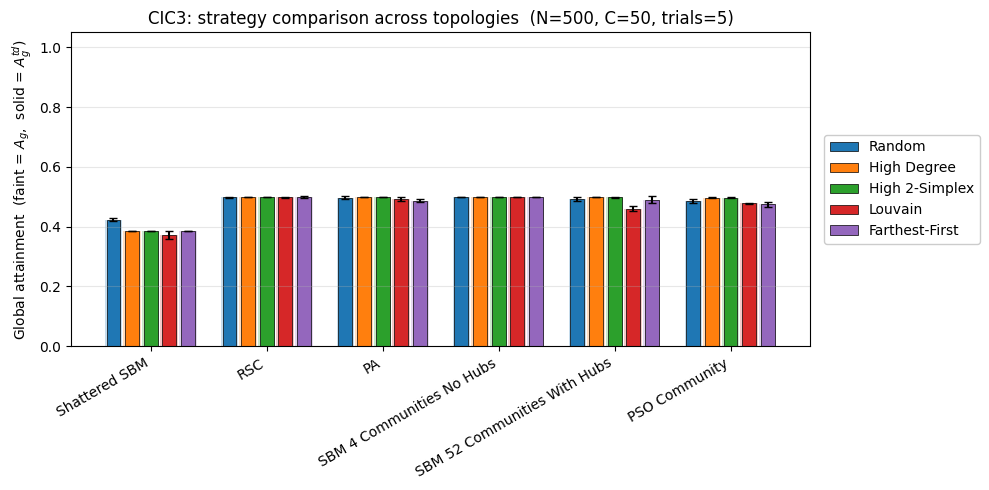

In [8]:
topo_names = [config["name"] for config in TOPOLOGY_CONFIGS]
strat_names = [s[0] for s in STRATEGIES]
strat_colors = plt.cm.tab10(np.linspace(0, 1, 10))[: len(strat_names)]

x = np.arange(len(topo_names))
group_width = 0.8
bar_width = group_width / len(strat_names)

fig, ax = plt.subplots(figsize=(10, 5))

for si, strat_name in enumerate(strat_names):
    means_td = [summary[t][strat_name]["A_g_td_mean"] for t in topo_names]
    stds_td = [summary[t][strat_name]["A_g_td_std"] for t in topo_names]
    means_raw = [summary[t][strat_name]["A_g_mean"] for t in topo_names]

    offset = (si - (len(strat_names) - 1) / 2) * bar_width
    # Faint raw A_g bar behind
    ax.bar(
        x + offset, means_raw, width=bar_width * 0.95,
        color=strat_colors[si], alpha=0.25,
        edgecolor="none",
        # label=f"{strat_name} (A_g)" if si == 0 else None,
    )
    # A_g^td bar with error bars in front
    ax.bar(
        x + offset, means_td, width=bar_width * 0.75,
        color=strat_colors[si], edgecolor="black", linewidth=0.5,
        yerr=stds_td, capsize=3,
        label=strat_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(topo_names, rotation=30, ha="right")
ax.set_ylabel(r"Global attainment  (faint = $A_g$,  solid = $A_g^{td}$)")
ax.set_ylim(0, 1.05)
ax.set_title(
    f"CIC3: strategy comparison across topologies  "
    f"(N={N}, C={C}, trials={NUM_TRIALS})"
)
ax.legend(
    loc="center left",           # Anchor point on the legend box
    bbox_to_anchor=(1.01, 0.5),  # (x, y) coordinates: just outside right edge, vertically centered
    framealpha=1
)

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/cic3_strategy_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Plot: distribution of per-contagion attainment

One subplot per topology, boxplot of per-contagion `A_i^td` pooled
across trials. A strategy that hits the same mean `A_g^td` with a
tighter per-contagion distribution is filling quotas more evenly.
A long lower tail means some contagions were badly underserved.

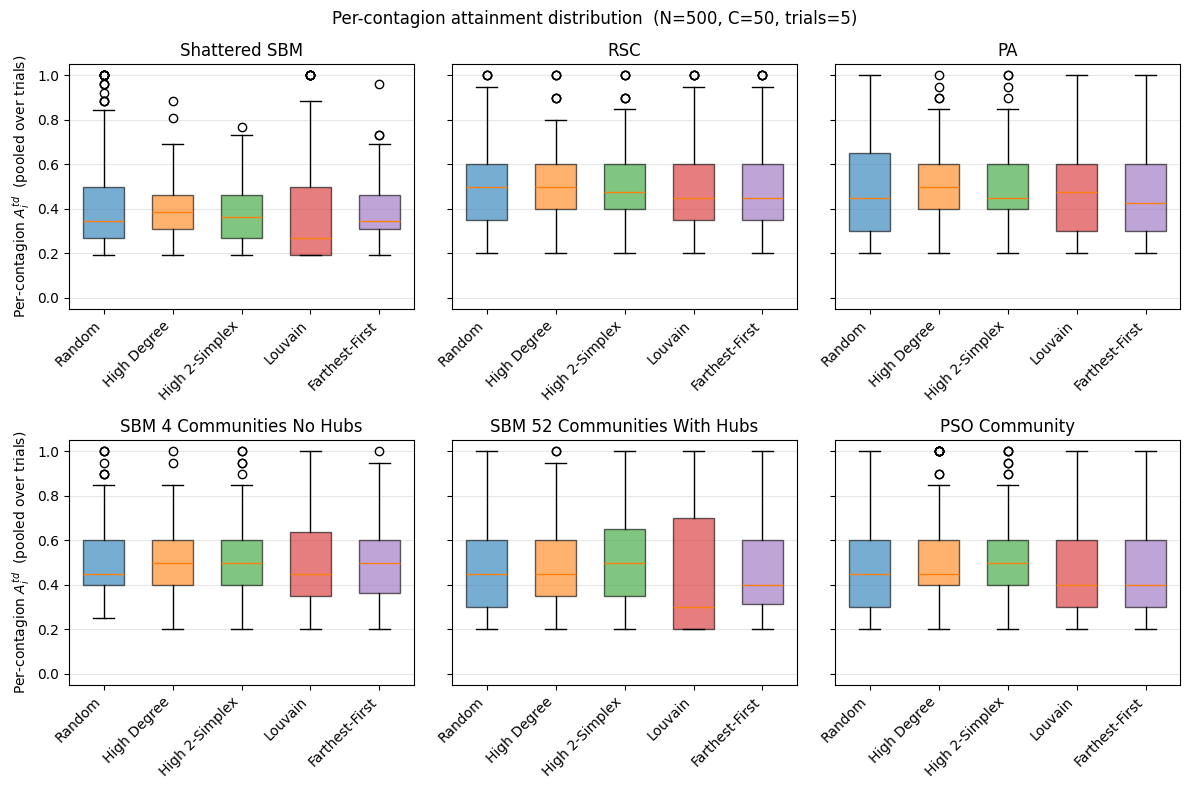

In [9]:
import math

ncols = 3
nrows = math.ceil(len(topo_names) / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True,
)
axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]

for i, ax in enumerate(axes_flat):
    if i >= len(topo_names):
        ax.axis("off")
        continue
    name = topo_names[i]
    data = [summary[name][s]["A_i_td_pooled"] for s in strat_names]
    bp = ax.boxplot(
        data, tick_labels=strat_names, patch_artist=True, widths=0.6,
    )
    for patch, color in zip(bp["boxes"], strat_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    if i % ncols == 0:
        ax.set_ylabel(r"Per-contagion $A_i^{td}$  (pooled over trials)")

fig.suptitle(
    f"Per-contagion attainment distribution  (N={N}, C={C}, trials={NUM_TRIALS})",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("../figures/cic3_per_contagion_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Plot: overlapping per-contagion attainment PDFs

Same data as the boxplot above, rendered as overlapping density curves
so you can see shape differences that a 5-number boxplot hides — e.g.
bimodality (some contagions fully filled, others zero), heavy left
tails (a handful of badly-underserved contagions), or a narrow spike
at 1.0 (all contagions saturated).

Dependency-free — uses `np.histogram(density=True)` rather than a KDE.

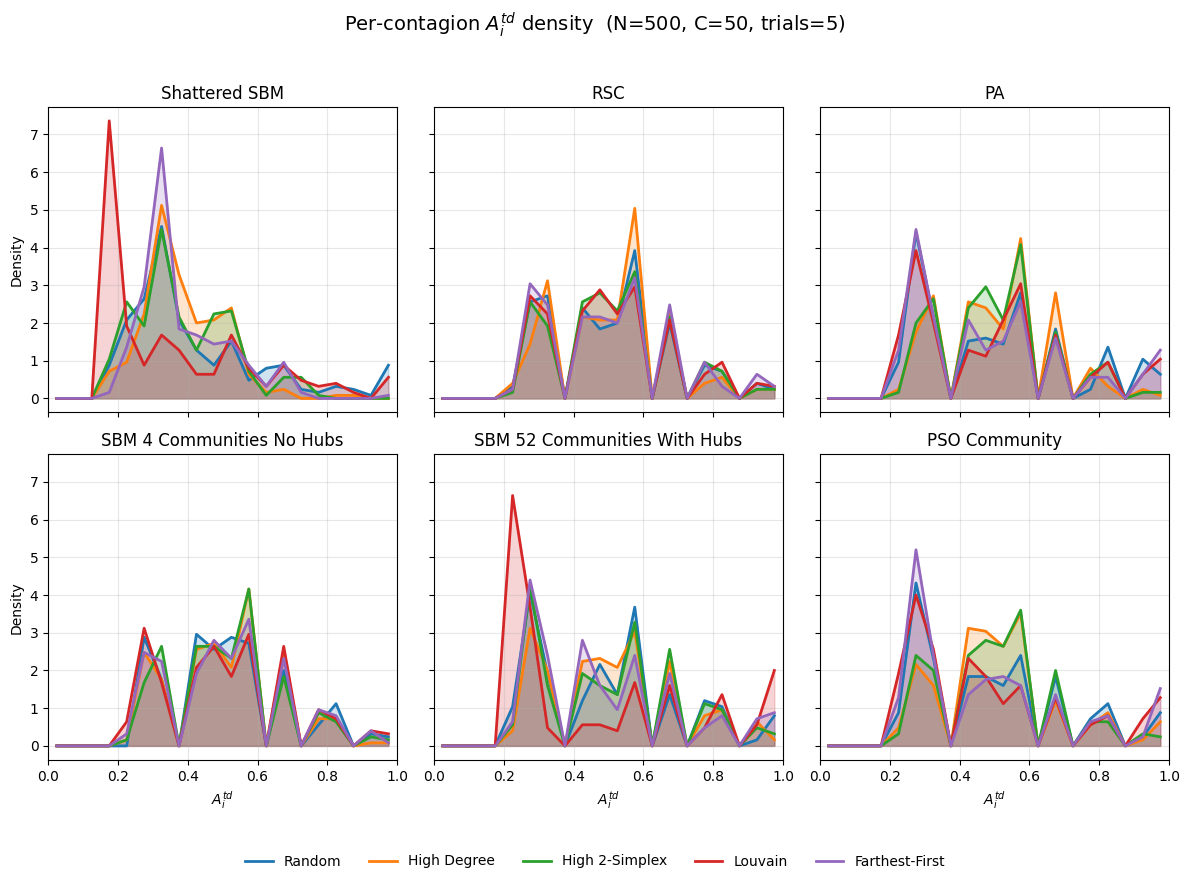

In [10]:
import matplotlib.pyplot as plt
import numpy as np

PDF_BINS = 20
n_plots = len(topo_names)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4 * ncols, 4 * nrows),
    sharey=True, sharex=True,
)
axes_flat = axes.flatten()

legend_handles = []
for i, ax in enumerate(axes_flat):
    if i < n_plots:
        name = topo_names[i]
        for si, strat_name in enumerate(strat_names):
            data = summary[name][strat_name]["A_i_td_pooled"]
            counts, edges = np.histogram(
                data, bins=PDF_BINS, range=(0.0, 1.0), density=True,
            )
            centers = 0.5 * (edges[:-1] + edges[1:])
            (line,) = ax.plot(
                centers, counts, color=strat_colors[si], lw=2,
                label=strat_name,
            )
            ax.fill_between(centers, 0, counts, color=strat_colors[si], alpha=0.2)
            if i == 0:
                legend_handles.append(line)

        ax.set_title(name)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("Density")
        if i >= n_plots - ncols:
            ax.set_xlabel(r"$A_i^{td}$")
    else:
        ax.axis('off')

fig.legend(
    handles=legend_handles,
    labels=strat_names,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(strat_names),
    frameon=False,
)

fig.suptitle(
    f"Per-contagion $A_i^{{td}}$ density  (N={N}, C={C}, trials={NUM_TRIALS})",
    fontsize=14, y=1.02
)

fig.tight_layout()
fig.savefig("../figures/cic3_per_contagion_pdf.png", dpi=200, bbox_inches="tight")
plt.show()

## ANOVA: is `Random` materially different on `Twitter Mutual`?

On every other topology a degree- or community-aware strategy beats
`Random`. On `Twitter Mutual` the ranking flips and `Random` posts the
highest mean `A_g^td`. Below we test that effect formally.

We pool the per-contagion `A_i^td` across trials (one observation per
contagion per trial) and run a one-way ANOVA across all five strategies
on `Twitter Mutual`. If the omnibus is significant we follow up with
Welch t-tests of `Random` against each other strategy, Bonferroni-
corrected over the four pairwise tests.


In [11]:
from scipy import stats

TARGET_TOPO = "Shattered SBM"
groups = {s: summary[TARGET_TOPO][s]["A_i_td_pooled"] for s in strat_names}

# Omnibus one-way ANOVA across all five strategies
F, p_omni = stats.f_oneway(*groups.values())
print(f"One-way ANOVA across strategies on {TARGET_TOPO!r}:")
print(f"  F = {F:.3f},  p = {p_omni:.3e}")
print(f"  group sizes: {[len(g) for g in groups.values()]}")
print(f"  group means:  " + ", ".join(
    f"{s}={groups[s].mean():.3f}" for s in strat_names))

# Pairwise Welch t-tests: Random vs each other strategy
print(f"\nPairwise Welch t-tests (Random vs other), Bonferroni m=4:")
others = [s for s in strat_names if s != "Random"]
for s in others:
    t, p = stats.ttest_ind(groups["Random"], groups[s], equal_var=False)
    p_bonf = min(1.0, p * len(others))
    diff = groups["Random"].mean() - groups[s].mean()
    flag = "***" if p_bonf < 0.001 else ("**" if p_bonf < 0.01 else ("*" if p_bonf < 0.05 else ""))
    print(f"  Random vs {s:<16s}  diff={diff:+.3f}  t={t:+.2f}  "
          f"p={p:.2e}  p_bonf={p_bonf:.2e}  {flag}")


One-way ANOVA across strategies on 'Shattered SBM':
  F = 3.542,  p = 6.982e-03
  group sizes: [250, 250, 250, 250, 250]
  group means:  Random=0.424, High Degree=0.385, High 2-Simplex=0.385, Louvain=0.373, Farthest-First=0.385

Pairwise Welch t-tests (Random vs other), Bonferroni m=4:
  Random vs High Degree       diff=+0.039  t=+2.70  p=7.22e-03  p_bonf=2.89e-02  *
  Random vs High 2-Simplex    diff=+0.039  t=+2.56  p=1.09e-02  p_bonf=4.35e-02  *
  Random vs Louvain           diff=+0.050  t=+2.72  p=6.80e-03  p_bonf=2.72e-02  *
  Random vs Farthest-First    diff=+0.039  t=+2.60  p=9.65e-03  p_bonf=3.86e-02  *


## Topology statistics

Side-by-side comparison of the structural properties that plausibly
explain the strategy ranking flip on `Twitter Mutual`. For each
topology we plot the degree-distribution CCDF, local clustering
coefficient PDF, and triangle-participation CCDF on a single figure
with all topologies overlaid (analogous to the per-contagion `A_i^td`
PDF chart above). For graphs with N > 5000 the clustering coefficient
is computed on a uniform random sample of nodes to keep the cell fast.


computing stats for Shattered SBM...
computing stats for RSC...
computing stats for PA...
computing stats for SBM 4 Communities No Hubs...
computing stats for SBM 52 Communities With Hubs...
computing stats for PSO Community...


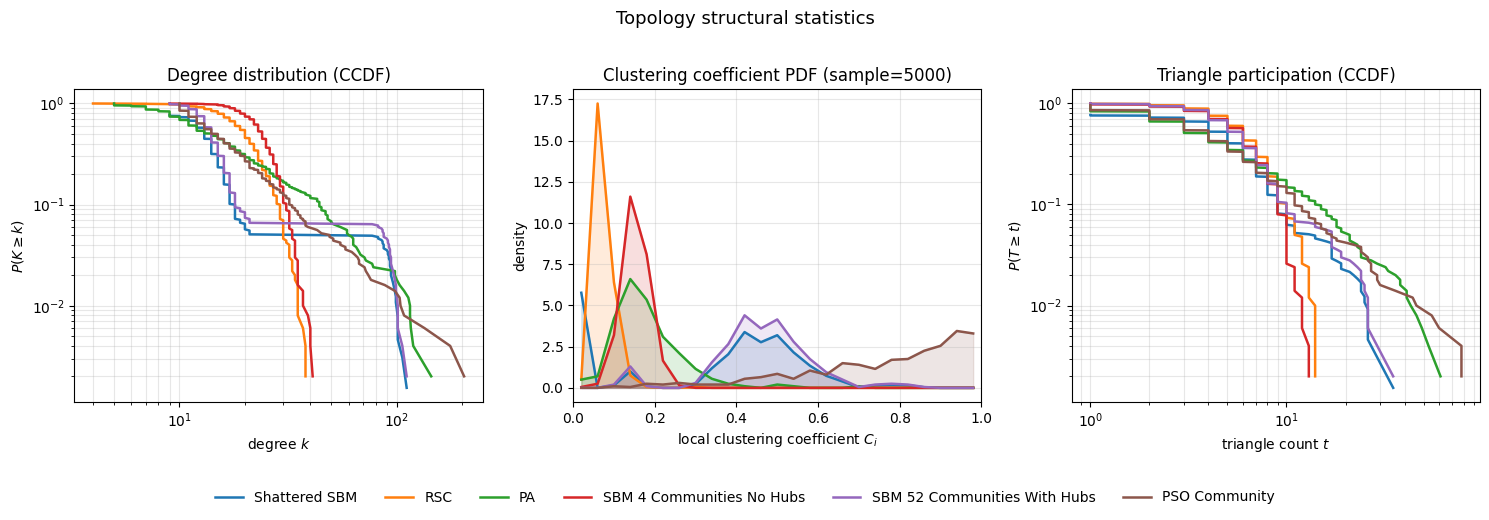


Topology                               N       <k>       <C>     <t_i>
----------------------------------------------------------------------
Shattered SBM                        650     14.65     0.353      5.03
RSC                                  500     20.29     0.073      6.34
PA                                   500     20.54     0.177      6.15
SBM 4 Communities No Hubs            500     24.03     0.153      5.90
SBM 52 Communities With Hubs         500     19.05     0.458      6.54
PSO Community                        500     19.94     0.762      5.94


In [12]:
import numpy as np
import matplotlib.pyplot as plt

CLUSTERING_SAMPLE = 5000   # cap for local clustering computation

def degree_array(links):
    return np.array([len(nb) for nb in links], dtype=int)

def triangle_participation(triangles):
    return np.array([len(tri) for tri in triangles], dtype=int)

def local_clustering(links, sample_size=None, rng=None):
    N_nodes = len(links)
    if sample_size is not None and N_nodes > sample_size:
        rng = rng or np.random.default_rng(0)
        idxs = rng.choice(N_nodes, size=sample_size, replace=False)
    else:
        idxs = np.arange(N_nodes)
    nb_sets = [set(nb) for nb in links]
    out = np.zeros(len(idxs))
    for oi, i in enumerate(idxs):
        nbs = links[i]
        k = len(nbs)
        if k < 2:
            continue
        tri = 0
        for ai in range(len(nbs)):
            sa = nb_sets[nbs[ai]]
            for bi in range(ai + 1, len(nbs)):
                if nbs[bi] in sa:
                    tri += 1
        out[oi] = 2 * tri / (k * (k - 1))
    return out

def ccdf(values):
    v = np.sort(np.asarray(values))
    n = len(v)
    # P(X >= v) for each v: complement of empirical CDF
    p = 1.0 - np.arange(n) / n
    return v, p

# Compute stats once per topology (expensive on Twitter)
topo_stats = {}
for name in topo_names:
    print(f"computing stats for {name}...")
    topo = topologies[name]
    deg = degree_array(topo["links"])
    tri = triangle_participation(topo["triangles"])
    clu = local_clustering(topo["links"], sample_size=CLUSTERING_SAMPLE)
    topo_stats[name] = {"degree": deg, "triangle_part": tri, "clustering": clu}

topo_colors = plt.cm.tab10(np.linspace(0, 1, 10))[: len(topo_names)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax_deg, ax_clu, ax_tri = axes

# --- Degree CCDF (log-log) ---
for ti, name in enumerate(topo_names):
    v, p = ccdf(topo_stats[name]["degree"])
    mask = v > 0
    ax_deg.loglog(v[mask], p[mask], color=topo_colors[ti], lw=1.8, label=name)
ax_deg.set_xlabel("degree $k$")
ax_deg.set_ylabel(r"$P(K \geq k)$")
ax_deg.set_title("Degree distribution (CCDF)")
ax_deg.grid(alpha=0.3, which="both")

# --- Local clustering coefficient PDF ---
CLU_BINS = 25
for ti, name in enumerate(topo_names):
    counts, edges = np.histogram(
        topo_stats[name]["clustering"], bins=CLU_BINS, range=(0.0, 1.0),
        density=True,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax_clu.plot(centers, counts, color=topo_colors[ti], lw=1.8, label=name)
    ax_clu.fill_between(centers, 0, counts, color=topo_colors[ti], alpha=0.15)
ax_clu.set_xlabel("local clustering coefficient $C_i$")
ax_clu.set_ylabel("density")
ax_clu.set_title(f"Clustering coefficient PDF (sample={CLUSTERING_SAMPLE})")
ax_clu.set_xlim(0, 1)
ax_clu.grid(alpha=0.3)

# --- Triangle participation CCDF (log-log) ---
for ti, name in enumerate(topo_names):
    v, p = ccdf(topo_stats[name]["triangle_part"])
    mask = v > 0
    if not mask.any():
        # Topology has zero triangle participation everywhere; skip but keep legend slot
        ax_tri.loglog([], [], color=topo_colors[ti], lw=1.8, label=name)
        continue
    ax_tri.loglog(v[mask], p[mask], color=topo_colors[ti], lw=1.8, label=name)
ax_tri.set_xlabel(r"triangle count $t$")
ax_tri.set_ylabel(r"$P(T \geq t)$")
ax_tri.set_title("Triangle participation (CCDF)")
ax_tri.grid(alpha=0.3, which="both")

# Single legend below the figure
handles, labels = ax_deg.get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02),
    ncol=len(topo_names), frameon=False,
)
fig.suptitle("Topology structural statistics", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("../figures/cic3_topology_statistics.png", dpi=200, bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'Topology':<32s}{'N':>8s}{'<k>':>10s}{'<C>':>10s}{'<t_i>':>10s}")
print("-" * 70)
for name in topo_names:
    s = topo_stats[name]
    print(f"{name:<32s}{topologies[name]['N']:>8d}"
          f"{s['degree'].mean():>10.2f}{s['clustering'].mean():>10.3f}"
          f"{s['triangle_part'].mean():>10.2f}")
